<a href="https://colab.research.google.com/github/Ishrath-Begum/product-sales-analysis/blob/main/Product_Sales_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PENS AND PRINTERS -PRODUCT SALES**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Data Science/product_sales.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   week               15000 non-null  int64  
 1   sales_method       15000 non-null  object 
 2   customer_id        15000 non-null  object 
 3   nb_sold            15000 non-null  int64  
 4   revenue            13926 non-null  float64
 5   years_as_customer  15000 non-null  int64  
 6   nb_site_visits     15000 non-null  int64  
 7   state              15000 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 937.6+ KB


#Observations
Dataset with
1.   Rows-15000,Columns-8

2.   Mix of Types:Numbers and Category with some missing values in columns











In [ ]:
df.head()

,week,sales_method,customer_id,nb_sold,revenue,years_as_customer,nb_site_visits,state
0,2,Email,2e72d641-95ac-497b-bbf8-4861764a7097,10,NaN,0,24,Arizona
1,6,Email + Call,3998a98d-70f5-44f7-942e-789bb8ad2fe7,15,225.47,1,28,Kansas
2,5,Call,d1de9884-8059-4065-b10f-86eef57e4a44,11,52.55,6,26,Wisconsin
3,4,Email,78aa75a4-ffeb-4817-b1d0-2f030783c5d7,11,NaN,3,25,Indiana
4,3,Email,10e6d446-10a5-42e5-8210-1b5438f70922,9,90.49,0,28,Illinois


In [ ]:
df.tail()

,week,sales_method,customer_id,nb_sold,revenue,years_as_customer,nb_site_visits,state
14995,4,Call,17267b41-d048-4346-8b90-7f787690a836,10,50.82,0,22,Pennsylvania
14996,5,Call,09e10d6f-4508-4b27-895e-4db11ce8302b,10,52.33,1,27,Kansas
14997,1,Call,839653cb-68c9-48cb-a097-0a5a3b2b298b,7,34.87,4,22,West Virginia
14998,6,Call,e4dad70a-b23b-407c-8bd3-e32ea00fae17,13,64.90,2,27,New Jersey
14999,5,Email + Call,4e077235-7c17-4054-9997-7a890336a214,13,NaN,4,25,Illinois


In [ ]:
df.describe()

,week,nb_sold,revenue,years_as_customer,nb_site_visits
count,15000.000000,15000.000000,13926.000000,15000.000000,15000.000000
mean,3.098267,10.084667,93.934943,4.965933,24.990867
std,1.656420,1.812213,47.435312,5.044952,3.500914
min,1.000000,7.000000,32.540000,0.000000,12.000000
25%,2.000000,9.000000,52.470000,1.000000,23.000000
50%,3.000000,10.000000,89.500000,3.000000,25.000000
75%,5.000000,11.000000,107.327500,7.000000,27.000000
max,6.000000,16.000000,238.320000,63.000000,41.000000


**DATA CLEANING**

In [ ]:
df.isnull().sum()

,0
week,0
sales_method,0
customer_id,0
nb_sold,0
revenue,1074
years_as_customer,0
nb_site_visits,0
state,0


**Revenue**:There are 1074 missing values in this Column

<Axes: >

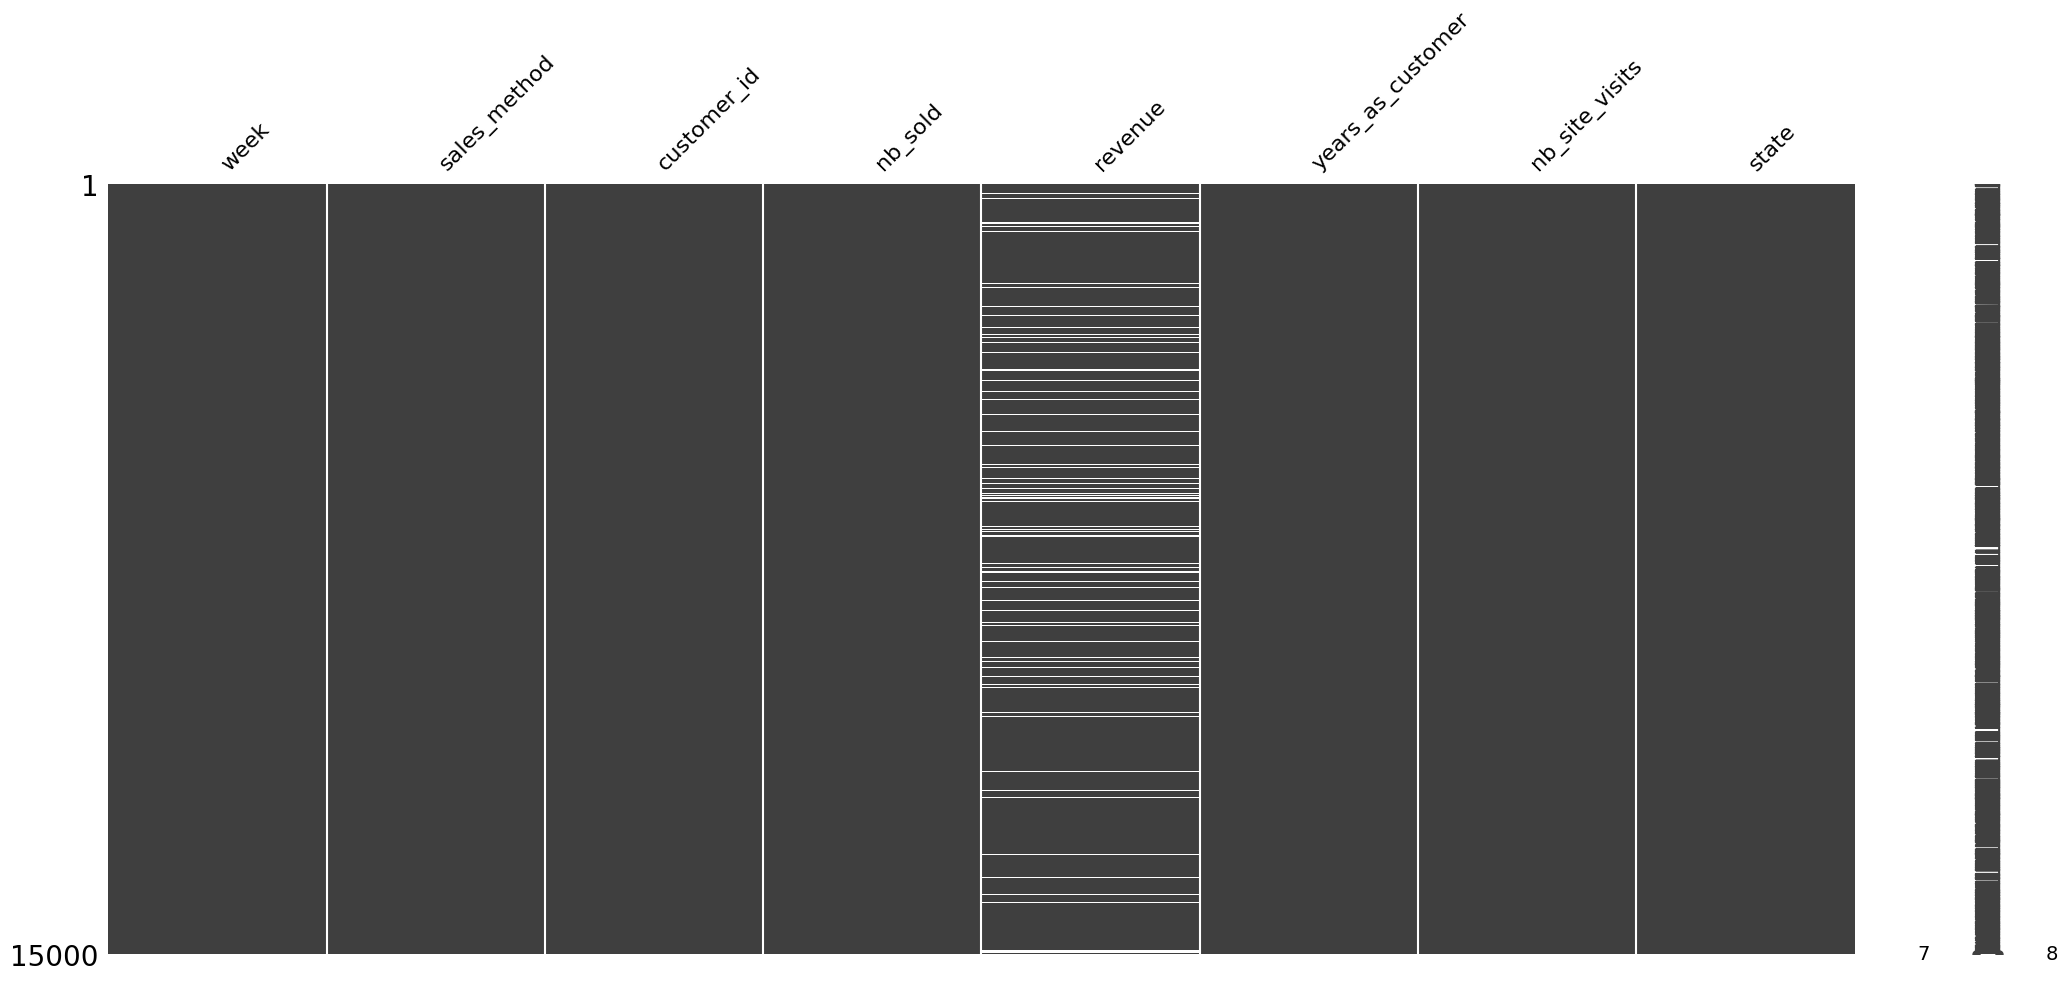

In [ ]:
msno.matrix(df)

In [ ]:
df['revenue'].fillna(df['revenue'].median())

,revenue
0,89.50
1,225.47
2,52.55
3,89.50
4,90.49
...,...
14995,50.82
14996,52.33
14997,34.87
14998,64.90


In [ ]:
df['revenue'].isnull().sum()

np.int64(1074)

In [ ]:
df['revenue']= df.groupby('sales_method')['revenue'].transform(
    lambda x: x.fillna(x.mean())
)


Filling Missing Values in "Revenue" with the average revenue of each sales method group

In [ ]:
df['revenue']

,revenue
0,97.126645
1,225.470000
2,52.550000
3,97.126645
4,90.490000
...,...
14995,50.820000
14996,52.330000
14997,34.870000
14998,64.900000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   week               15000 non-null  int64  
 1   sales_method       15000 non-null  object 
 2   customer_id        15000 non-null  object 
 3   nb_sold            15000 non-null  int64  
 4   revenue            15000 non-null  float64
 5   years_as_customer  15000 non-null  int64  
 6   nb_site_visits     15000 non-null  int64  
 7   state              15000 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 937.6+ KB


<Axes: >

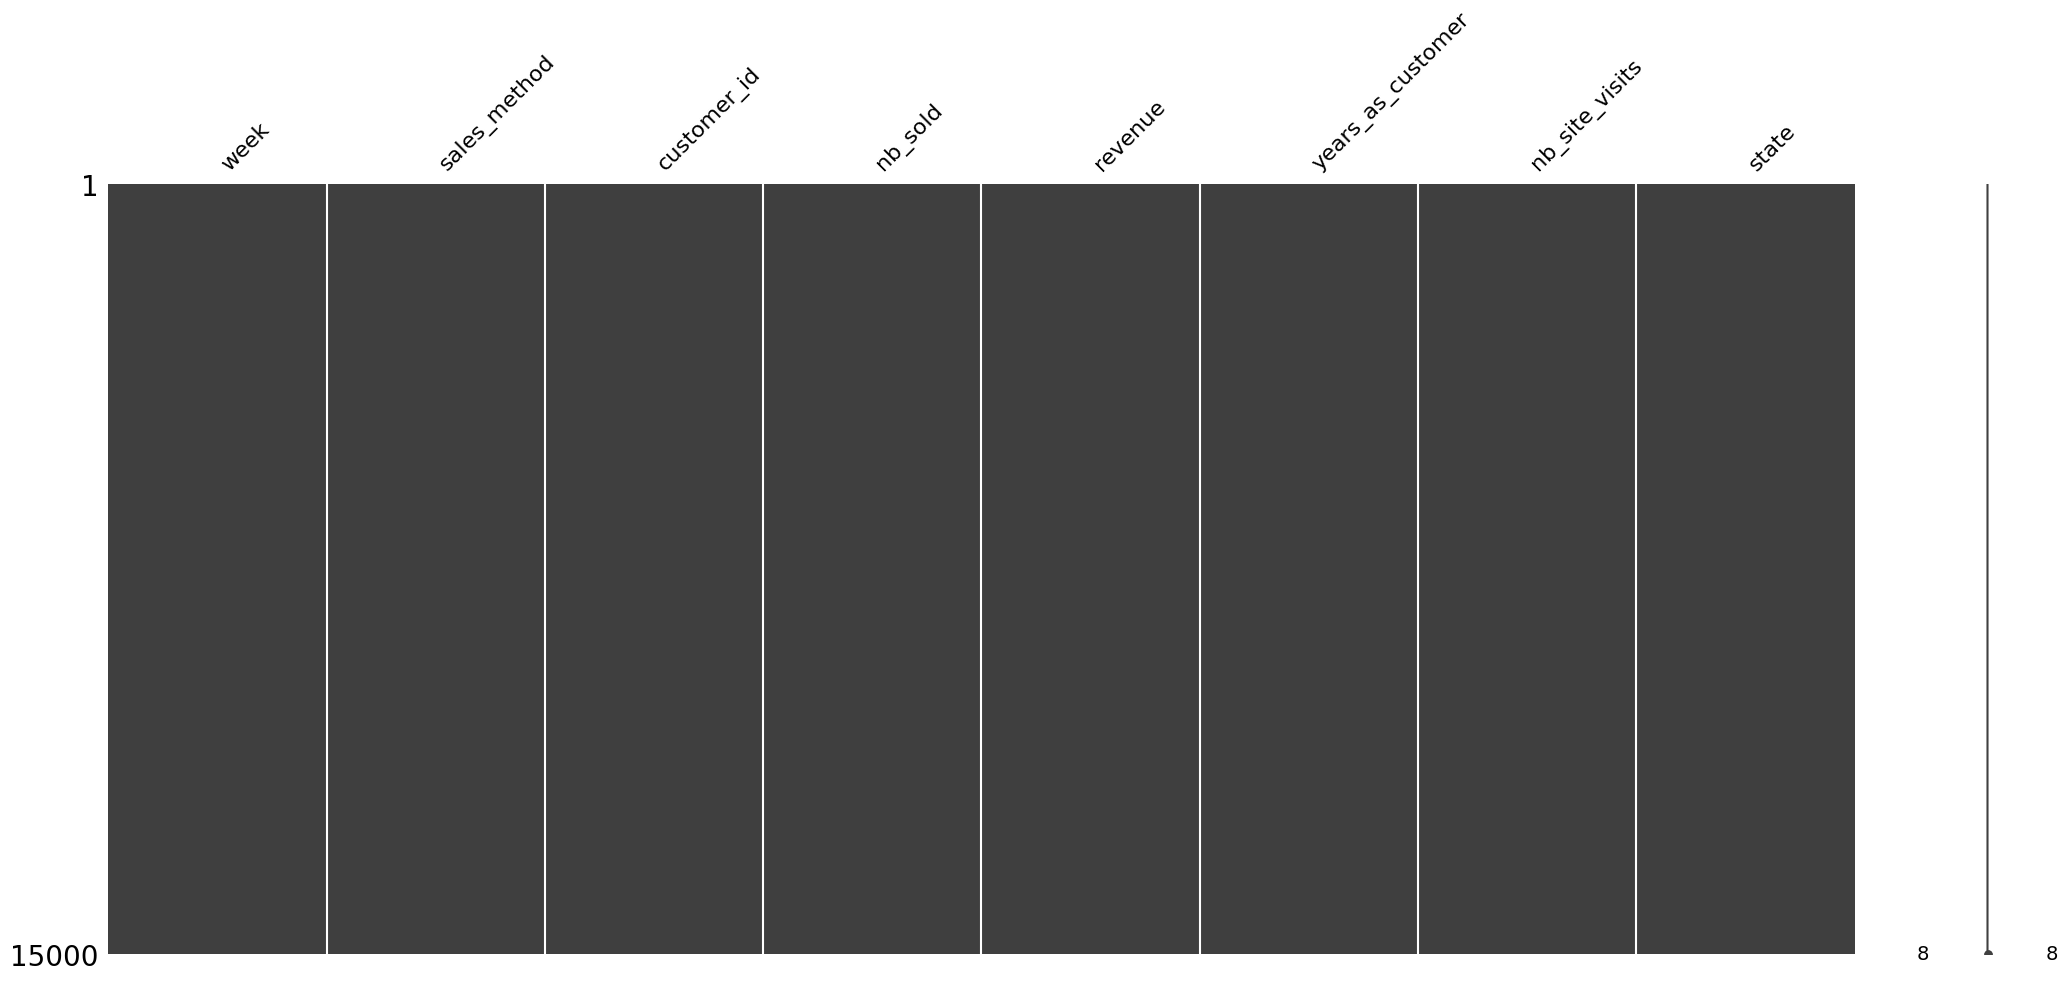

In [ ]:
msno.matrix(df)

**UNIVARIATE ANALYSIS**

 **OBSERVATIONS**

performing Boxplot to identifing Outliers in the data

<Axes: xlabel='nb_sold'>

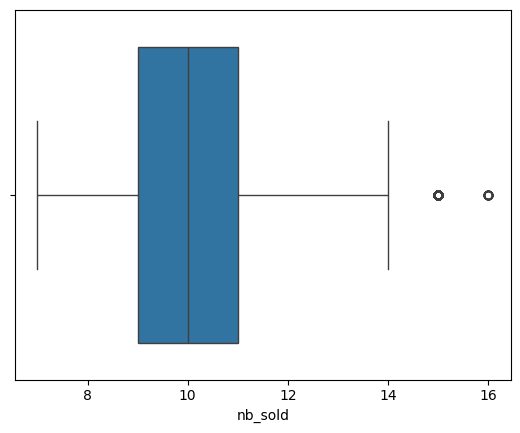

In [ ]:
sns.boxplot(df,x='nb_sold')

There are few outliers in "nb_sold" column

In [ ]:
Q1=df['nb_sold'].quantile(0.25)
Q3=df['nb_sold'].quantile(0.75)
IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df.loc[(df['nb_sold']<lower_bound) | (df['nb_sold']>upper_bound),'nb_sold']=np.nan


**OBSERVATION**

* We used IQR method to fill Outliers.

* Any value too far below or above the normal range was replaced with NaN to avoid skewing the analysis.

*  And same method is Applying for remaining Columns also.

<Axes: xlabel='nb_sold'>

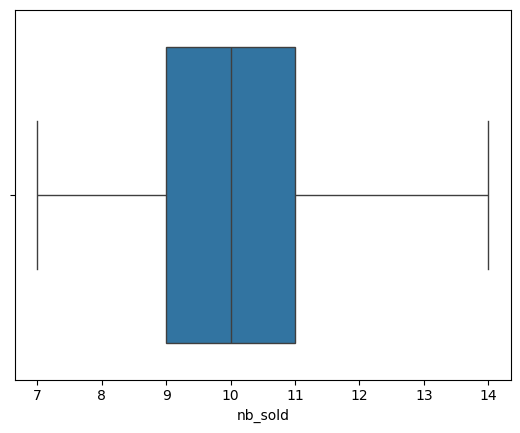

In [ ]:
sns.boxplot(df,x='nb_sold')

<Axes: xlabel='nb_site_visits'>

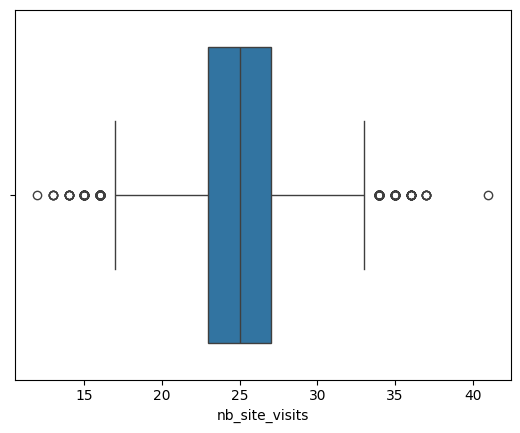

In [ ]:
sns.boxplot(df,x='nb_site_visits')

In [ ]:
Q1=df['nb_site_visits'].quantile(0.25)
Q3=df['nb_site_visits'].quantile(0.75)
IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df.loc[(df['nb_site_visits']<lower_bound) | (df['nb_site_visits']>upper_bound),'nb_site_visits']=np.nan

<Axes: xlabel='nb_site_visits'>

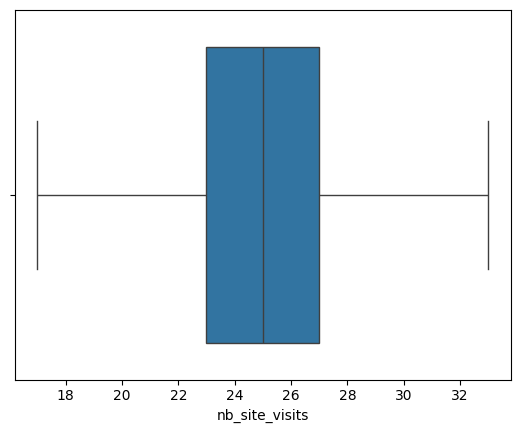

In [ ]:
sns.boxplot(df,x='nb_site_visits')

<Axes: xlabel='years_as_customer'>

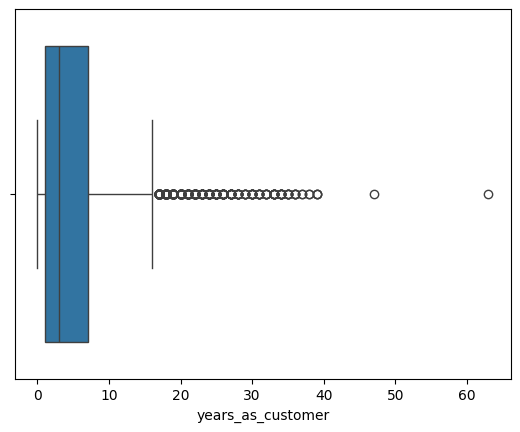

In [ ]:
sns.boxplot(df,x='years_as_customer')

In [ ]:
Q1=df['years_as_customer'].quantile(0.25)
Q3=df['years_as_customer'].quantile(0.75)
IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df.loc[(df['years_as_customer']<lower_bound) | (df['years_as_customer']>upper_bound),'years_as_customer']=np.nan

<Axes: xlabel='years_as_customer'>

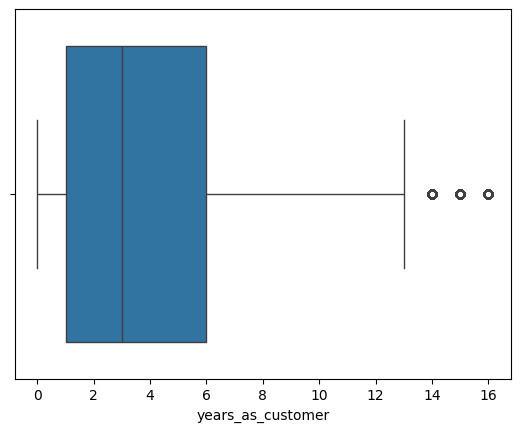

In [ ]:
sns.boxplot(df,x='years_as_customer')

<Axes: xlabel='week'>

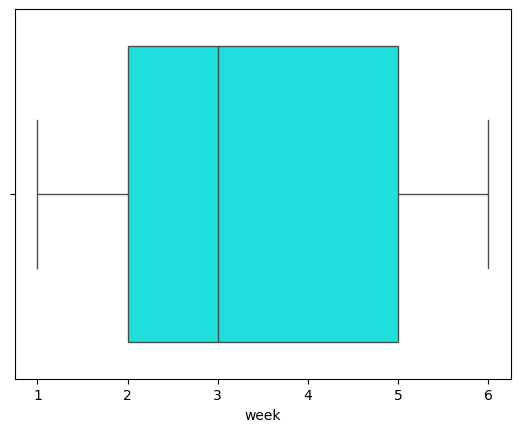

In [ ]:
sns.boxplot(df,x='week',color='aqua')

<Axes: xlabel='revenue'>

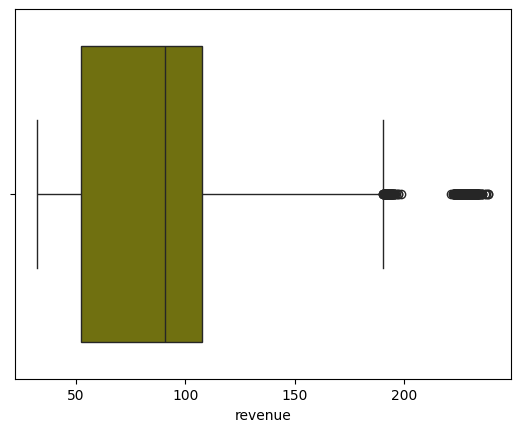

In [ ]:
sns.boxplot(df,x='revenue',color='olive')

In [ ]:
Q1=df['revenue'].quantile(0.25)
Q3=df['revenue'].quantile(0.75)
IQR=Q3-Q1

lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df.loc[(df['revenue']<lower_bound) | (df['revenue']>upper_bound),'revenue']=np.nan

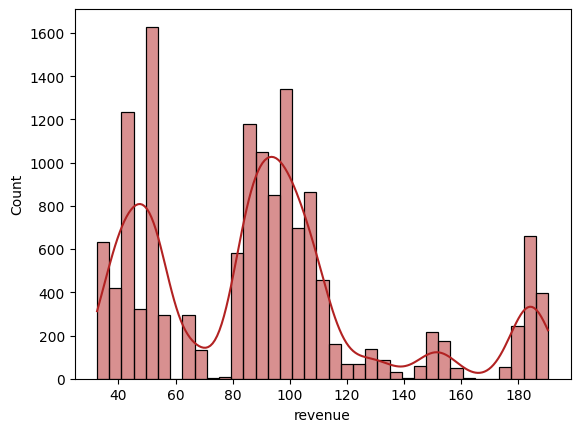

In [ ]:
sns.histplot(df,x='revenue',kde=True,color='firebrick')
plt.show()

**OBSERVATIONS**

* Multiple peaks: Revenue values around 50, 99, and 180 are common.

* Skewed right





In [ ]:
df['sales_method'].value_counts()

,count
sales_method,
Email,7456
Call,4962
Email + Call,2549
em + call,23
email,10


In [ ]:
df['state'].value_counts().sum()

np.int64(15000)

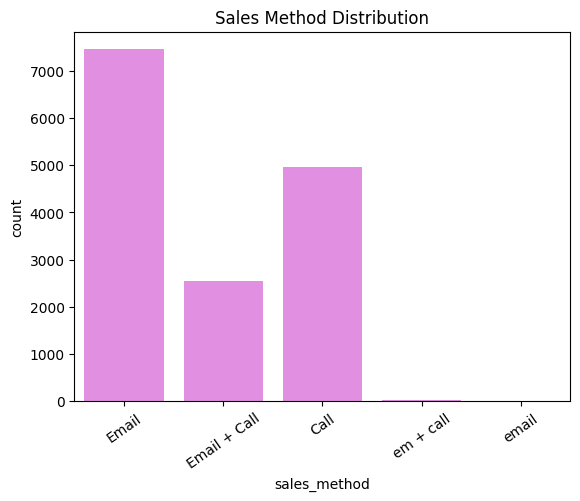

In [ ]:
sns.countplot(data=df,x='sales_method',color='violet')
plt.title('Sales Method Distribution')
plt.xticks(rotation=35)
plt.show()

**OBSERVATIONS**

- "Email" is used the most — over 7,000 times.
- "Call" is next — around 5,000.
- "Email + Call" is third — about 3,000.
- "email" and "em + call" look like typos — very few entries.




**BI VARIATE ANALYSIS**

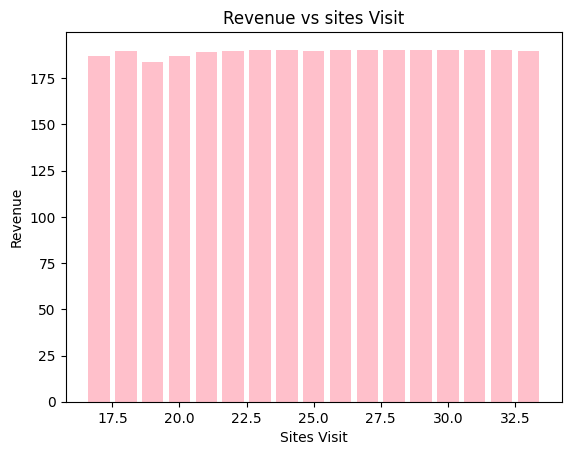

In [ ]:
plt.bar(data=df,x='nb_site_visits',height='revenue',color='pink')
plt.title('Revenue vs sites Visit')
plt.xlabel('Sites Visit')
plt.ylabel('Revenue')
plt.show()

**OBSERVATIONS**
- More visits = more revenue: As site visits increase, average revenue also goes up.
- Positive trend: The bars get taller from left to right, showing a clear upward pattern.


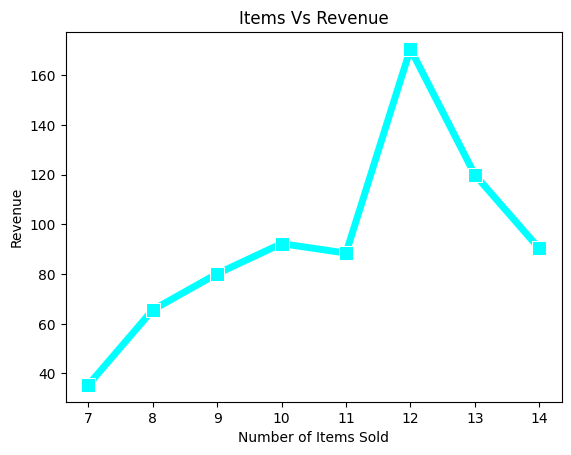

In [ ]:
sns.lineplot(df,x='nb_sold',y='revenue',linewidth=5,marker='s',markersize=10,errorbar=None,color='cyan')
plt.title('Items Vs Revenue')
plt.xlabel('Number of Items Sold')
plt.ylabel('Revenue')
plt.show()

**OBSERVATIONS**
- **General upward trend**: As more items are sold, revenue usually increases.
- Selling more items often leads to more revenue, but not always.


In [ ]:
df[['nb_sold','revenue','years_as_customer','nb_site_visits']].corr()

,nb_sold,revenue,years_as_customer,nb_site_visits
nb_sold,1.000000,0.551910,-0.087795,0.445568
revenue,0.551910,1.000000,-0.054933,0.244922
years_as_customer,-0.087795,-0.054933,1.000000,-0.048973
nb_site_visits,0.445568,0.244922,-0.048973,1.000000


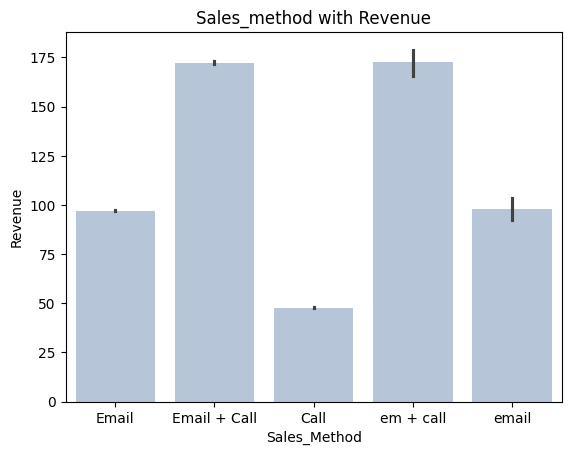

In [ ]:
sns.barplot(df,x='sales_method',y='revenue',color='lightsteelblue')
plt.title('Sales_method with Revenue')
plt.xlabel('Sales_Method')
plt.ylabel('Revenue')
plt.show()

**OBSERVATIONS**
- "Email + Call" and "em + call" bring in the most revenue — both close to 175.
- "Call" alone earns the least — around 50.
- "Email" and "email" are in the middle — about 100 each.


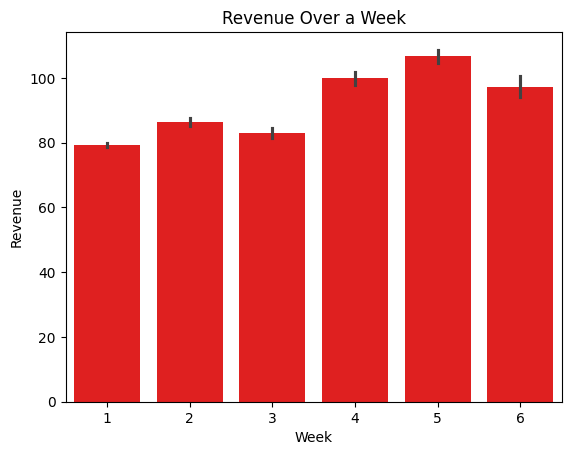

In [ ]:
sns.barplot(df,x='week',y='revenue',color='red')
plt.title('Revenue Over a Week')
plt.xlabel('Week')
plt.ylabel('Revenue')
plt.show()

**OBSERVATIONS**
- Revenue goes up each week, highest in week 5.
- Week 6 drops a little, but still strong.
- Overall trend is positive — things are improving over time.


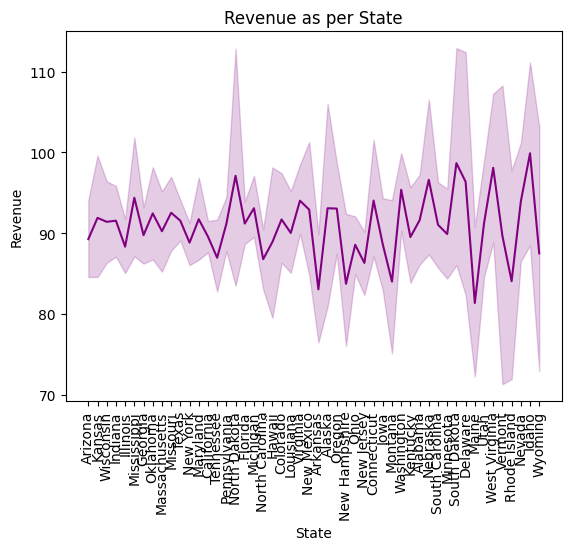

In [ ]:
sns.lineplot(df,x='state',y='revenue',color='purple')
plt.title('Revenue as per State')
plt.xlabel('State')
plt.ylabel('Revenue')
plt.xticks(rotation=90)
plt.show()

**Observations**
- Revenue varies by state
- Some states earn much more than others—there are clear peaks and dips.
- The purple shaded area shows how much the revenue might vary or how uncertain the data is.
- Wider shading


<function matplotlib.pyplot.show(close=None, block=None)>

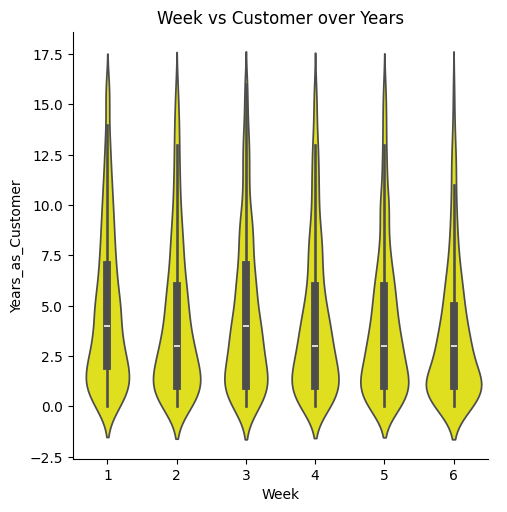

In [ ]:
sns.catplot(data=df,y='years_as_customer',x='week',kind='violin',color='yellow')
plt.title('Week vs Customer over Years')
plt.xlabel('Week')
plt.ylabel('Years_as_Customer')
plt.show

**OBSERVATIONS**
- Week 1 and Week 6 have a wide range of customer years — both new and long-time customers.
- Week 3 shows less variety — most customers have similar tenure.
- Week 5 has older customers on average — the middle line (median) is higher.
- Week 2 has a few very long-term customers, but most are newer.
- Week 4 has a flat spread — customer years are more evenly distributed


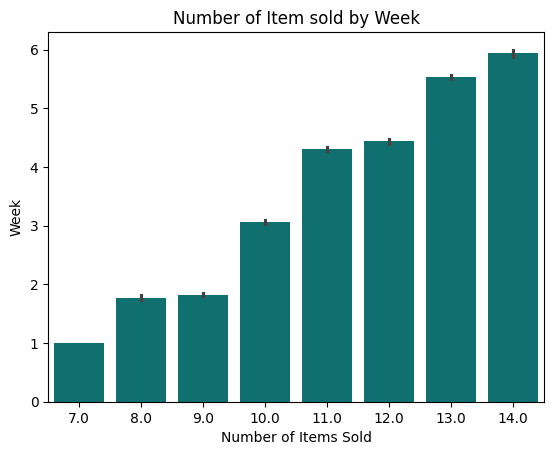

In [ ]:
sns.barplot(df,x='nb_sold',y='week',color='teal')
plt.title('Number of Item sold by Week')
plt.xlabel('Number of Items Sold')
plt.ylabel('Week')
plt.show()

**OBSERVATIONS**
- Upward Trend: There's a general increase in the number of items sold from Week 1 to Week 7, suggesting improving sales performance over time.
- Highest Sales: Week 7 has the highest number of items sold, around 14 units.
- Lowest Sales: Week 1 shows the lowest sales, around 7 units.


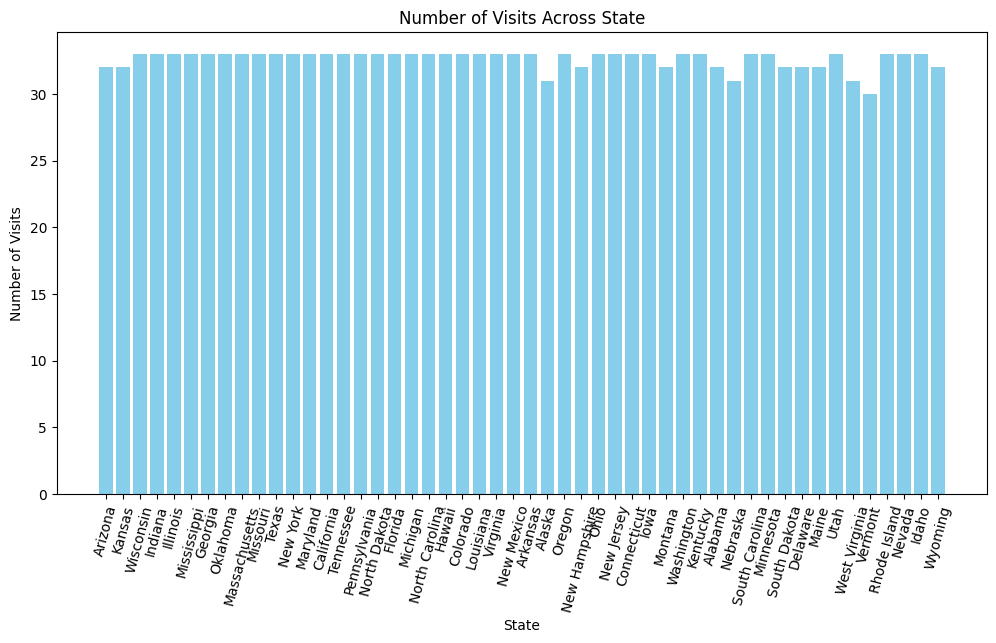

In [ ]:
plt.figure(figsize=(12,6))
plt.bar(data=df,x='state',height='nb_site_visits',color='skyblue')
plt.title("Number of Visits Across State")
plt.xlabel('State')
plt.ylabel('Number of Visits')
plt.xticks(rotation=75)
plt.show()

In [ ]:
df['state'].nunique()

50

In [ ]:
df['state'].value_counts()

,count
state,
California,1872
Texas,1187
New York,965
Florida,904
Illinois,617
Pennsylvania,598
Ohio,566
Michigan,498
Georgia,489


In [ ]:
top_states=df['state'].value_counts().nlargest(5).index
top_states


Index(['California', 'Texas', 'New York', 'Florida', 'Illinois'], dtype='object', name='state')

**OBSERVATIONS**
* In State col, There are 50 categories.
* Here,we are selecting only Top 5 States.

In [ ]:
df_subset=df[df['state'].isin(top_states)]
df_subset

,week,sales_method,customer_id,nb_sold,revenue,years_as_customer,nb_site_visits,state
4,3,Email,10e6d446-10a5-42e5-8210-1b5438f70922,9.0,90.4900,0.0,28.0,Illinois
10,3,Email,c40f2602-8a7c-429e-bf13-cb1ec9e5f92f,9.0,89.4900,4.0,28.0,Texas
11,2,Call,c20ab049-cbac-4ba7-8868-310aa89e0549,9.0,45.4200,2.0,23.0,New York
13,2,Email,6103bcac-9da6-4000-a0ce-fa2615cce846,10.0,101.5400,1.0,28.0,California
19,1,Email,ca2fcee8-81f2-455a-a766-5213c56a7775,9.0,90.9300,2.0,28.0,Florida
...,...,...,...,...,...,...,...,...
14981,6,Call,50608b92-2045-4851-be63-282f956660fa,14.0,68.9300,11.0,26.0,California
14988,2,Call,b6e0a974-616c-442c-b976-f36f5b3ef757,9.0,45.0100,4.0,26.0,California
14992,5,em + call,cd9e6945-ae21-4bed-a6cf-f0302e6c4795,12.0,173.4770,1.0,NaN,New York
14993,1,Email,3ec54950-652e-4d8a-bc49-8b5c770c6cd2,8.0,83.9800,2.0,21.0,Texas


In [ ]:
avg_revenue = df_subset.groupby('state')['revenue'].mean().sort_values(ascending=False)
avg_revenue


,revenue
state,
Texas,91.523676
Florida,91.172406
California,89.564689
New York,88.809880
Illinois,88.312546


**OBSERVATIONS**
* Top 5 states are grouping with revenue.

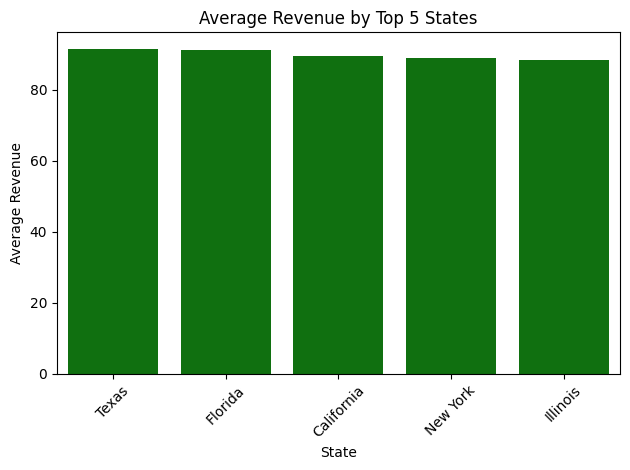

In [ ]:
sns.barplot(x=avg_revenue.index, y=avg_revenue.values,color='green')
plt.title('Average Revenue by Top 5 States')
plt.xlabel('State')
plt.ylabel('Average Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**OBSERVATIONS**

- Texas has the highest average revenue.
- Florida and California are close behind.
- New York and Illinois have slightly lower revenue.
- All five states have similar revenue levels, with small differences


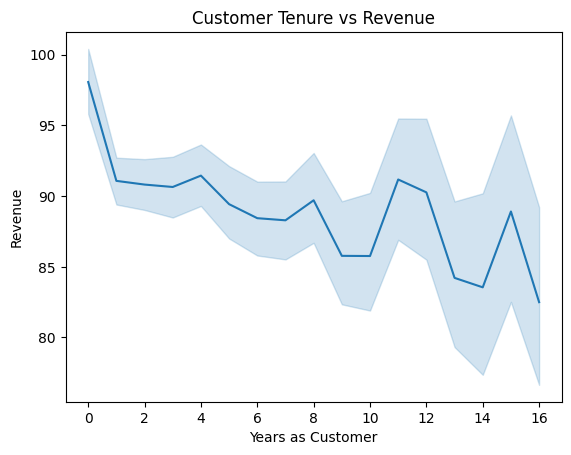

In [ ]:
sns.lineplot(x='years_as_customer', y='revenue', data=df)
plt.title('Customer Tenure vs Revenue')
plt.xlabel('Years as Customer')
plt.ylabel('Revenue')
plt.show()


Text(0, 0.5, 'Site visits')

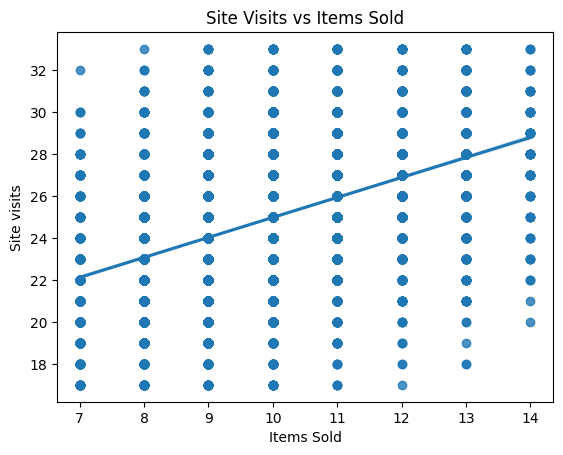

In [ ]:
sns.regplot(x='nb_sold', y='nb_site_visits', data=df)
plt.title('Site Visits vs Items Sold')
plt.xlabel('Items Sold')
plt.ylabel('Site visits')


**Observations**
- More items sold usually means more site visits.
- The points follow a clear upward trend.


Text(0, 0.5, 'Revenue')

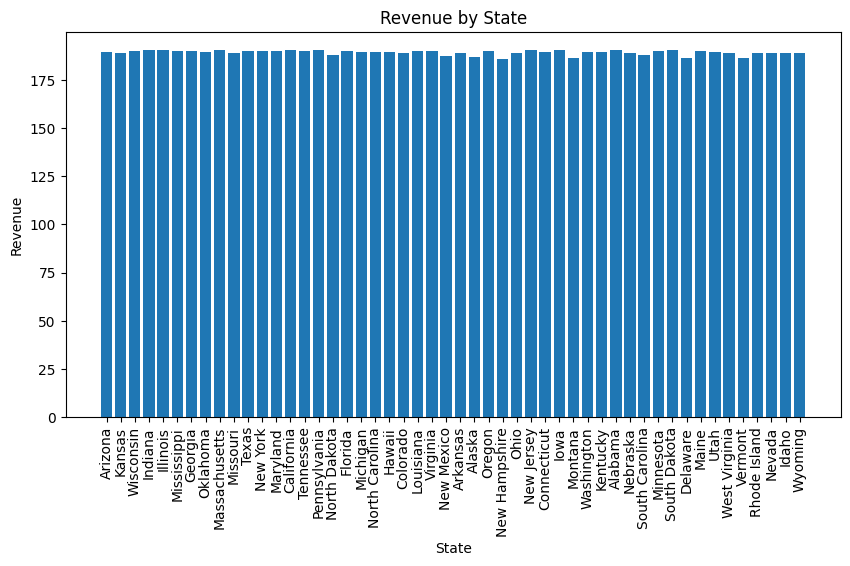

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(x='state', height='revenue',data=df)
plt.xticks(rotation=90)
plt.title('Revenue by State')
plt.xlabel('State')
plt.ylabel('Revenue')


Text(0, 0.5, 'Average Revenue')

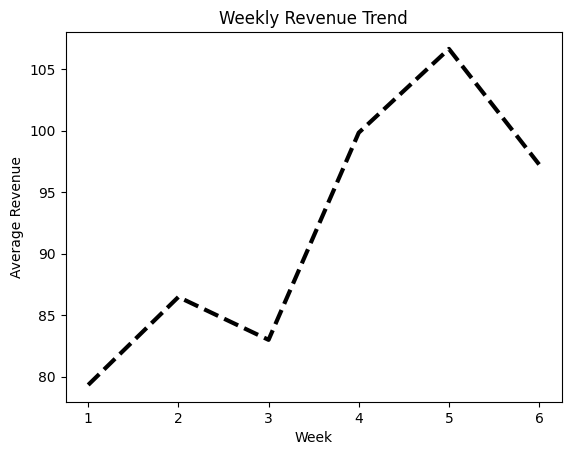

In [ ]:
weekly_revenue = df.groupby('week')['revenue'].mean().reset_index()
sns.lineplot(x='week', y='revenue', data=weekly_revenue,color="black",linestyle="dashed",linewidth=3)
plt.title('Weekly Revenue Trend')
plt.xlabel('Week')
plt.ylabel('Average Revenue')


**Observations**

- Revenue increased steadily from Week 1 to Week 5.
- Week 5 had the highest average revenue.
- Revenue dropped slightly in Week 6.
- The biggest jump happened between Week 3 and Week 4.
- Weeks 1 to 3 had lower and more stable revenue.


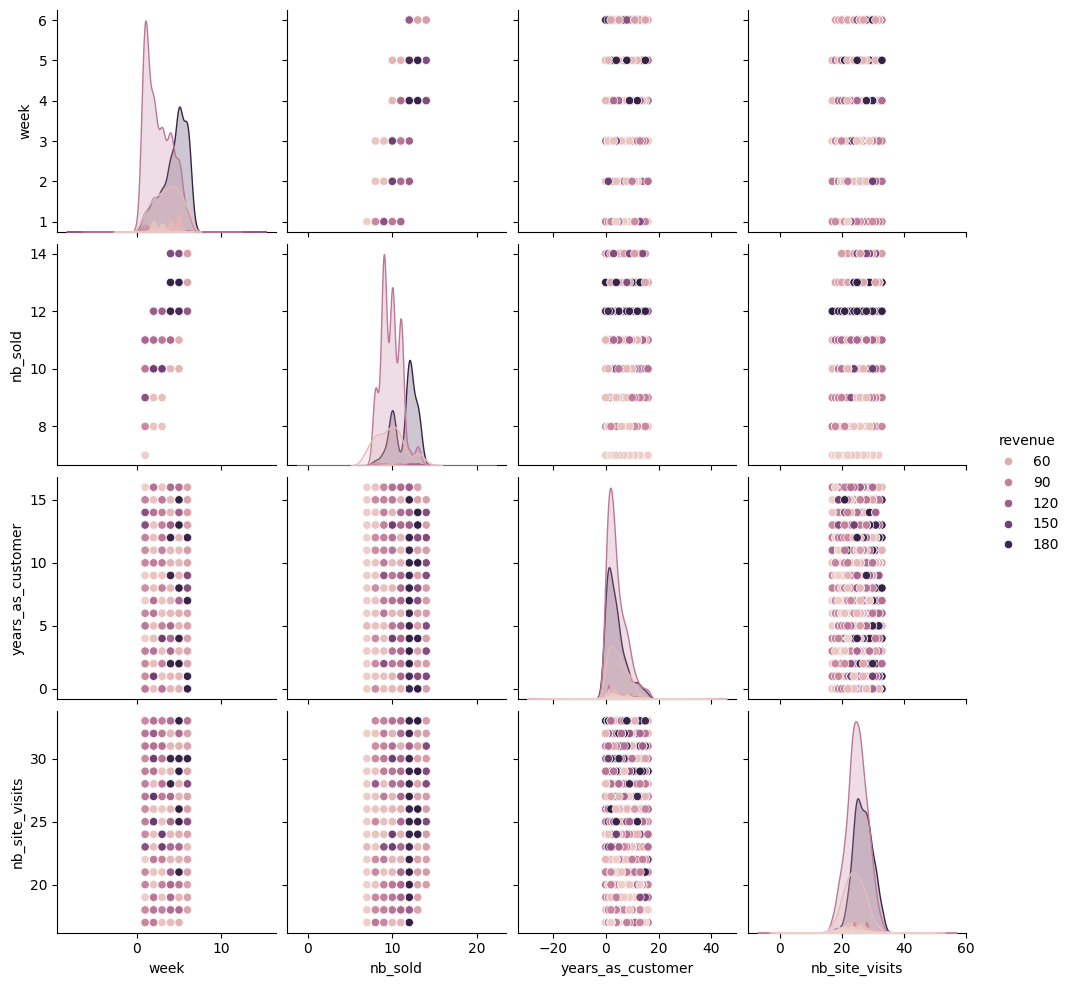

In [ ]:
sns.pairplot(data=df,hue='revenue')

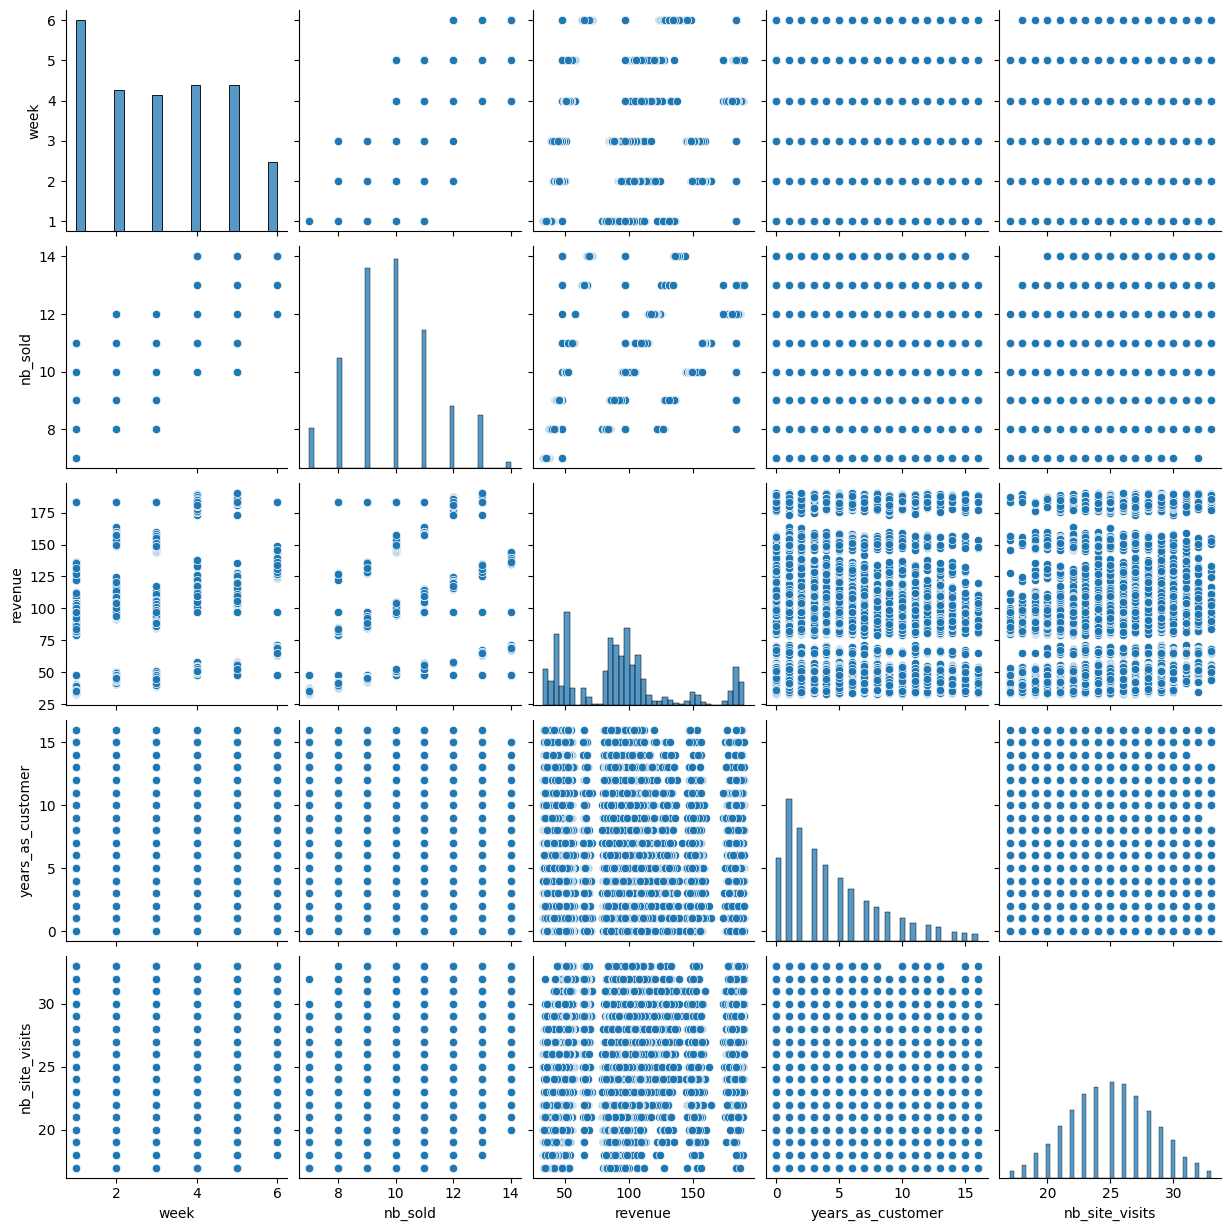

In [ ]:
sns.pairplot(data=df)

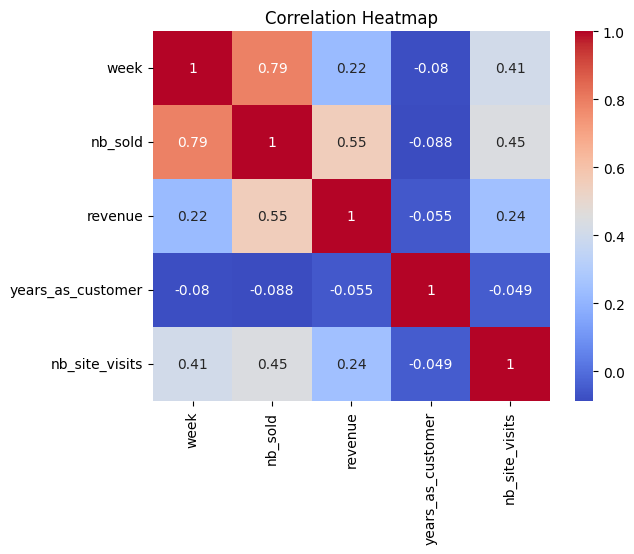

In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Create a correlation matrix
corr = numeric_df.corr()

# Plot the heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


**OBSERVATIONS**

- nb_sold increases as week goes up — they’re strongly linked.
- More items sold usually means more revenue.
- More site visits are slightly linked to more sales and revenue.
- years_as_customer doesn’t show strong connections with other columns.
